In [1]:
import pandas as pd
import seaborn as sns

In [2]:
df=pd.read_csv("Bengaluru_House_Data.csv")
df

,area_type,availability,location,size,society,total_sqft,bath,balcony,price
0,Super built-up Area,19-Dec,Electronic City Phase II,2 BHK,Coomee,1056,2.0,1.0,39.07
1,Plot Area,Ready To Move,Chikka Tirupathi,4 Bedroom,Theanmp,2600,5.0,3.0,120.00
2,Built-up Area,Ready To Move,Uttarahalli,3 BHK,NaN,1440,2.0,3.0,62.00
3,Super built-up Area,Ready To Move,Lingadheeranahalli,3 BHK,Soiewre,1521,3.0,1.0,95.00
4,Super built-up Area,Ready To Move,Kothanur,2 BHK,NaN,1200,2.0,1.0,51.00
...,...,...,...,...,...,...,...,...,...
13315,Built-up Area,Ready To Move,Whitefield,5 Bedroom,ArsiaEx,3453,4.0,0.0,231.00
13316,Super built-up Area,Ready To Move,Richards Town,4 BHK,NaN,3600,5.0,NaN,400.00
13317,Built-up Area,Ready To Move,Raja Rajeshwari Nagar,2 BHK,Mahla T,1141,2.0,1.0,60.00
13318,Super built-up Area,18-Jun,Padmanabhanagar,4 BHK,SollyCl,4689,4.0,1.0,488.00


In [3]:
df=df.drop(columns=['area_type','availability','society','balcony'])

In [4]:
df

,location,size,total_sqft,bath,price
0,Electronic City Phase II,2 BHK,1056,2.0,39.07
1,Chikka Tirupathi,4 Bedroom,2600,5.0,120.00
2,Uttarahalli,3 BHK,1440,2.0,62.00
3,Lingadheeranahalli,3 BHK,1521,3.0,95.00
4,Kothanur,2 BHK,1200,2.0,51.00
...,...,...,...,...,...
13315,Whitefield,5 Bedroom,3453,4.0,231.00
13316,Richards Town,4 BHK,3600,5.0,400.00
13317,Raja Rajeshwari Nagar,2 BHK,1141,2.0,60.00
13318,Padmanabhanagar,4 BHK,4689,4.0,488.00


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13320 entries, 0 to 13319
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   location    13319 non-null  object 
 1   size        13304 non-null  object 
 2   total_sqft  13320 non-null  object 
 3   bath        13247 non-null  float64
 4   price       13320 non-null  float64
dtypes: float64(2), object(3)
memory usage: 520.4+ KB


In [6]:
df['location'].value_counts

<bound method IndexOpsMixin.value_counts of 0        Electronic City Phase II
1                Chikka Tirupathi
2                     Uttarahalli
3              Lingadheeranahalli
4                        Kothanur
                   ...           
13315                  Whitefield
13316               Richards Town
13317       Raja Rajeshwari Nagar
13318             Padmanabhanagar
13319                Doddathoguru
Name: location, Length: 13320, dtype: object>

In [7]:
df['location'].isna().sum()

1

In [8]:
df['location'].value_counts()

location
Whitefield                        540
Sarjapur  Road                    399
Electronic City                   302
Kanakpura Road                    273
Thanisandra                       234
                                 ... 
Bapuji Layout                       1
1st Stage Radha Krishna Layout      1
BEML Layout 5th stage               1
singapura paradise                  1
Abshot Layout                       1
Name: count, Length: 1305, dtype: int64

In [9]:
df['location']=df['location'].fillna('Sarjapur Road')

In [10]:
df['location']=df['location'].apply(lambda x:x.strip())

In [11]:
df['size'].isnull().sum()

16

In [12]:
df['size'].value_counts()

size
2 BHK         5199
3 BHK         4310
4 Bedroom      826
4 BHK          591
3 Bedroom      547
1 BHK          538
2 Bedroom      329
5 Bedroom      297
6 Bedroom      191
1 Bedroom      105
8 Bedroom       84
7 Bedroom       83
5 BHK           59
9 Bedroom       46
6 BHK           30
7 BHK           17
1 RK            13
10 Bedroom      12
9 BHK            8
8 BHK            5
11 BHK           2
11 Bedroom       2
10 BHK           2
14 BHK           1
13 BHK           1
12 Bedroom       1
27 BHK           1
43 Bedroom       1
16 BHK           1
19 BHK           1
18 Bedroom       1
Name: count, dtype: int64

In [13]:
df['size']=df['size'].fillna('2 BHK')

In [14]:
df['bath'].isna().sum()

73

In [15]:
df['bath'].value_counts()

bath
2.0     6908
3.0     3286
4.0     1226
1.0      788
5.0      524
6.0      273
7.0      102
8.0       64
9.0       43
10.0      13
12.0       7
13.0       3
11.0       3
16.0       2
27.0       1
40.0       1
15.0       1
14.0       1
18.0       1
Name: count, dtype: int64

In [16]:
df['bath']=df['bath'].fillna(2)

In [17]:
df['bath']=df['bath'].astype(int)

In [18]:
loc=df['location'].value_counts()
loc_less_than_10=loc[loc<=10]
df['location']=df['location'].apply(lambda x:"others" if x in loc_less_than_10 else x)

In [19]:
out=[int(i.split()[0]) for i in df['size']]
df['bhk']=out
df

,location,size,total_sqft,bath,price,bhk
0,Electronic City Phase II,2 BHK,1056,2,39.07,2
1,Chikka Tirupathi,4 Bedroom,2600,5,120.00,4
2,Uttarahalli,3 BHK,1440,2,62.00,3
3,Lingadheeranahalli,3 BHK,1521,3,95.00,3
4,Kothanur,2 BHK,1200,2,51.00,2
...,...,...,...,...,...,...
13315,Whitefield,5 Bedroom,3453,4,231.00,5
13316,others,4 BHK,3600,5,400.00,4
13317,Raja Rajeshwari Nagar,2 BHK,1141,2,60.00,2
13318,Padmanabhanagar,4 BHK,4689,4,488.00,4


In [20]:
df['total_sqft'].value_counts()

total_sqft
1200    843
1100    221
1500    205
2400    196
600     180
       ... 
3580      1
2461      1
1437      1
2155      1
4689      1
Name: count, Length: 2117, dtype: int64

In [21]:
def clean_sqft(sqft):
    l=sqft.split("-")
    if len(l)==2:
        return float(l[0])+float(l[1])/2
    try:
        return float(l[0])
    except: 
        return None
df['total_sqft']=df['total_sqft'].apply(clean_sqft)                

In [22]:
df['total_sqft'].value_counts()

total_sqft
1200.0    843
1100.0    221
1500.0    205
2400.0    199
600.0     180
         ... 
555.0       1
4830.0      1
2383.0      1
3080.0      1
4689.0      1
Name: count, Length: 1999, dtype: int64

In [23]:
df.duplicated().sum()

1052

In [24]:
df.drop_duplicates(inplace=True)

In [25]:
df['total_sqft'].isna().sum()

44

In [26]:
df['total_sqft']=df['total_sqft'].fillna(round(df['total_sqft'].mean()))

In [27]:
df['total_sqft'].describe()

count    12268.000000
mean      1593.074365
std       1292.728327
min          1.000000
25%       1100.000000
50%       1300.000000
75%       1704.250000
max      52272.000000
Name: total_sqft, dtype: float64

In [28]:
df['price_per_sqft']=df['price']*100000/df['total_sqft']
df

,location,size,total_sqft,bath,price,bhk,price_per_sqft
0,Electronic City Phase II,2 BHK,1056.0,2,39.07,2,3699.810606
1,Chikka Tirupathi,4 Bedroom,2600.0,5,120.00,4,4615.384615
2,Uttarahalli,3 BHK,1440.0,2,62.00,3,4305.555556
3,Lingadheeranahalli,3 BHK,1521.0,3,95.00,3,6245.890861
4,Kothanur,2 BHK,1200.0,2,51.00,2,4250.000000
...,...,...,...,...,...,...,...
13314,Green Glen Layout,3 BHK,1715.0,3,112.00,3,6530.612245
13315,Whitefield,5 Bedroom,3453.0,4,231.00,5,6689.834926
13316,others,4 BHK,3600.0,5,400.00,4,11111.111111
13317,Raja Rajeshwari Nagar,2 BHK,1141.0,2,60.00,2,5258.545136


In [29]:
df=df[df['total_sqft']/df['bhk']>=300]
df['total_sqft'].describe()

count    11540.000000
mean      1632.012158
std       1318.295051
min        300.000000
25%       1125.000000
50%       1322.000000
75%       1740.000000
max      52272.000000
Name: total_sqft, dtype: float64

<Axes: xlabel='price_per_sqft'>

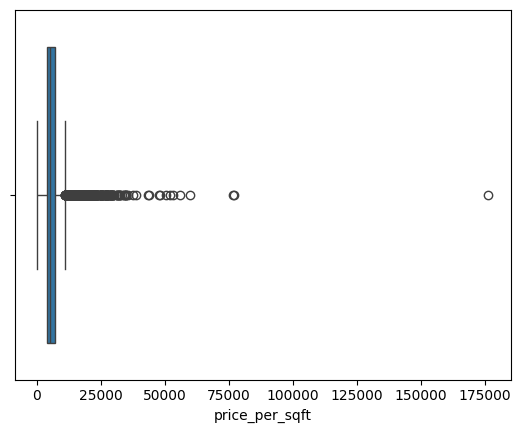

In [30]:
sns.boxplot(x='price_per_sqft',data=df)

In [31]:
q1=df['price_per_sqft'].quantile(0.25)
q3=df['price_per_sqft'].quantile(0.75)

IQR=q3-q1

lower=q1-0.5*IQR
upper=q3+0.5*IQR

In [32]:
df=df[(df['price_per_sqft']>=lower) & (df['price_per_sqft']<=upper)]

In [33]:
df

,location,size,total_sqft,bath,price,bhk,price_per_sqft
0,Electronic City Phase II,2 BHK,1056.0,2,39.07,2,3699.810606
1,Chikka Tirupathi,4 Bedroom,2600.0,5,120.00,4,4615.384615
2,Uttarahalli,3 BHK,1440.0,2,62.00,3,4305.555556
3,Lingadheeranahalli,3 BHK,1521.0,3,95.00,3,6245.890861
4,Kothanur,2 BHK,1200.0,2,51.00,2,4250.000000
...,...,...,...,...,...,...,...
13310,Rachenahalli,2 BHK,1050.0,2,52.71,2,5020.000000
13312,Bellandur,2 BHK,1262.0,2,47.00,2,3724.247227
13314,Green Glen Layout,3 BHK,1715.0,3,112.00,3,6530.612245
13315,Whitefield,5 Bedroom,3453.0,4,231.00,5,6689.834926


<Axes: xlabel='price_per_sqft'>

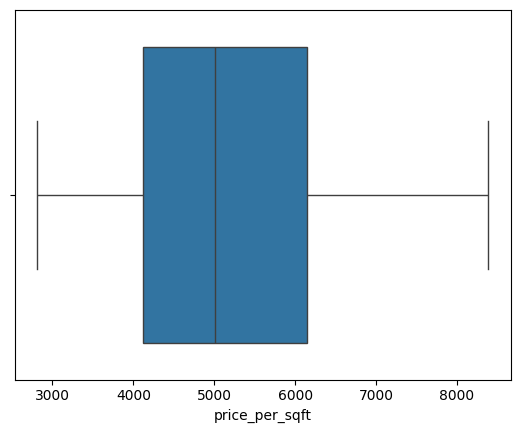

In [34]:
sns.boxplot(x='price_per_sqft',data=df)

In [35]:
df.reset_index(inplace=True)

In [36]:
df=df.drop(['index','price_per_sqft','size'],axis=1)
df

,location,total_sqft,bath,price,bhk
0,Electronic City Phase II,1056.0,2,39.07,2
1,Chikka Tirupathi,2600.0,5,120.00,4
2,Uttarahalli,1440.0,2,62.00,3
3,Lingadheeranahalli,1521.0,3,95.00,3
4,Kothanur,1200.0,2,51.00,2
...,...,...,...,...,...
9487,Rachenahalli,1050.0,2,52.71,2
9488,Bellandur,1262.0,2,47.00,2
9489,Green Glen Layout,1715.0,3,112.00,3
9490,Whitefield,3453.0,4,231.00,5


In [37]:
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split,GridSearchCV
from sklearn.metrics import r2_score


In [38]:
encoder=LabelEncoder()
df['encoded_loc']=encoder.fit_transform(df['location'])
df

,location,total_sqft,bath,price,bhk,encoded_loc
0,Electronic City Phase II,1056.0,2,39.07,2,78
1,Chikka Tirupathi,2600.0,5,120.00,4,60
2,Uttarahalli,1440.0,2,62.00,3,225
3,Lingadheeranahalli,1521.0,3,95.00,3,158
4,Kothanur,1200.0,2,51.00,2,150
...,...,...,...,...,...,...
9487,Rachenahalli,1050.0,2,52.71,2,192
9488,Bellandur,1262.0,2,47.00,2,43
9489,Green Glen Layout,1715.0,3,112.00,3,86
9490,Whitefield,3453.0,4,231.00,5,234


In [39]:
x=df.drop(['location','price'],axis=1)
y=df.price
x

,total_sqft,bath,bhk,encoded_loc
0,1056.0,2,2,78
1,2600.0,5,4,60
2,1440.0,2,3,225
3,1521.0,3,3,158
4,1200.0,2,2,150
...,...,...,...,...
9487,1050.0,2,2,192
9488,1262.0,2,2,43
9489,1715.0,3,3,86
9490,3453.0,4,5,234


In [40]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.3,random_state=42)

In [41]:
model=RandomForestRegressor(random_state=42)

In [42]:
params={
    "n_estimators":[100,150,200,250,300],
    "max_depth":[3,4,5,6,7]
}

In [43]:
grid=GridSearchCV(estimator=model,param_grid=params,cv=5)
grid.fit(x_train,y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestR...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': [3, 4, ...], 'n_estimators': [100, 150, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score is also displayed;- >

In [44]:
grid.score(x_train,y_train)

0.8676380852757799

In [45]:
grid.score(x_test,y_test)

0.85349996470154

In [46]:
from sklearn.linear_model import  LinearRegression

In [47]:
L_model=LinearRegression()
L_model.fit(x_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [48]:
L_model.score(x_train,y_train)

0.8203885764233041

In [49]:
L_model.score(x_test,y_test)

0.8777050339574984

In [50]:
df.to_csv("Cleaned_df.csv")

In [51]:
import joblib
with open("RF_model.joblib","wb")as file:
    joblib.dump(grid,file)